# EV Motor - Remanufacturing Inventory Simulation

This notebook models a closed-loop remanufacturing inventory system for EV motors with:

1. customer demand each week
2. stochastic core returns from fulfilled demand
3. stochastic remanufacturing yield after a reman lead time
4. stochastic supplier lead times for new units
5. a simulation-based reorder policy evaluated with Monte Carlo runs

The notebook now uses a **simulation-based** supplier policy:

- the reorder point is treated as a policy input to test,
- supplier orders are triggered from the simulated state,
- order quantity is based on the simulated **inventory position**,
- pipeline inventory includes stock on hand, supplier units already on order, and expected reman output from active reman jobs.


In [12]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List, Tuple

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


## Parameters

In [13]:
@dataclass
class Params:
    # Inventory limits
    max_stock:          int   = 60     # order-up-to level for supplier replenishment
    initial_stock:      int   = 60     # stock at simulation start

    # Demand
    demand_per_week:    int   = 25     # constant customer demand (units/week)

    # Closed-loop rates
    return_rate:        float = 0.87   # fraction of customers who return old cores
    reman_success_rate: float = 0.90   # fraction of returned cores successfully reman'd
    reman_lead_time:    float = 2.0    # weeks to complete remanufacturing

    # Supplier replenishment policy
    reorder_point:      int   = 35     # trigger supplier review when inventory position <= this value
    lt_mean:            float = 2.0    # supplier lead time mean (weeks)
    lt_std:             float = 0.5    # supplier lead time std dev (weeks)
    review_period:      float = 1.0    # review inventory once per week

    # Cost parameters
    purchase_cost_per_unit:     float = 400.0   # supplier purchase cost per unit
    order_cost_per_order:       float = 250.0   # fixed cost each time a supplier order is placed
    holding_cost_per_unit_week: float = 4.0     # holding cost per unit per week

    # Simulation
    sim_weeks:          int   = 104    # 2 years


In [14]:
p = Params()

# Descriptive averages shown for context only.
net_return_per_week = p.demand_per_week * p.return_rate * p.reman_success_rate
net_supplier_need_per_week = p.demand_per_week - net_return_per_week

print('Baseline settings')
print(f'  Max stock (order-up-to)    : {p.max_stock} units')
print(f'  Initial stock              : {p.initial_stock} units')
print(f'  Reorder point              : {p.reorder_point} units')
print(f'  Demand per week            : {p.demand_per_week} units')
print(f'  Avg reman returned/week    : {net_return_per_week:.2f} units')
print(f'  Avg external need/week     : {net_supplier_need_per_week:.2f} units')
print()
print('Policy interpretation')
print('  Review the system every week.')
print('  If simulated inventory position <= reorder point, place a supplier order.')
print('  Supplier order quantity = max_stock - inventory_position.')
print('  Inventory position includes stock on hand, supplier units on order,')
print('  and expected reman output from active reman work-in-process.')
print()
print('Cost model used in this notebook')
print('  Total Cost = Purchase Cost + Ordering Cost + Holding Cost')
print(f'  Purchase cost per unit     : {p.purchase_cost_per_unit:.2f}')
print(f'  Order cost per order       : {p.order_cost_per_order:.2f}')
print(f'  Holding cost per unit-week : {p.holding_cost_per_unit_week:.2f}')


Baseline settings
  Max stock (order-up-to)    : 60 units
  Initial stock              : 60 units
  Reorder point              : 35 units
  Demand per week            : 25 units
  Avg reman returned/week    : 19.57 units
  Avg external need/week     : 5.43 units

Policy interpretation
  Review the system every week.
  If simulated inventory position <= reorder point, place a supplier order.
  Supplier order quantity = max_stock - inventory_position.
  Inventory position uses current stock plus supplier units already on order.
  Reman WIP is not converted into deterministic expected arrivals in the policy.


## SimPy Simulation

In [15]:
class IMSystem:
    """
    Closed-loop remanufacturing inventory system with a simulation-based
    order-up-to supplier policy.

    Processes
    ---------
    weekly_demand   : ships demand, records stockouts, launches reman jobs
    reman_process   : converts returned cores into good units after reman lead time
    reorder_monitor : reviews simulated inventory position once per week
    supplier_order  : supplier delivery arrives after a random lead time
    """

    def __init__(self, env: simpy.Environment, params: Params, rng: np.random.Generator):
        self.env = env
        self.p = params
        self.rng = rng
        self.stock = params.initial_stock
        self.supplier_units_on_order = 0
        self.reman_units_in_process = 0

        # Log lists
        self.log_time: List[float] = []
        self.log_stock: List[int] = []
        self.log_inventory_position: List[float] = []
        self.log_reman_wip_expected: List[float] = []
        self.log_demand: List[Tuple] = []            # (week, qty)
        self.log_stockouts: List[Tuple] = []         # (week, units_short)
        self.log_reman_in: List[Tuple] = []          # (week, units_added)
        self.log_orders: List[Tuple] = []            # (week_placed, qty, week_arrived)
        self.log_supplier_in: List[Tuple] = []       # (week, units_added)

        self._snap()

        env.process(self.weekly_demand())
        env.process(self.reorder_monitor())

    def expected_reman_pipeline(self) -> float:
        # Active reman jobs are still stochastic, so we use expected good output from
        # the current WIP as part of pipeline inventory seen by the supplier policy.
        return self.reman_units_in_process * self.p.reman_success_rate

    def inventory_position(self) -> float:
        # Pipeline-aware inventory position used for ordering decisions.
        return self.stock + self.supplier_units_on_order + self.expected_reman_pipeline()

    def _snap(self):
        self.log_time.append(self.env.now)
        self.log_stock.append(self.stock)
        self.log_inventory_position.append(self.inventory_position())
        self.log_reman_wip_expected.append(self.expected_reman_pipeline())

    def _add_to_stock(self, qty: int):
        self.stock += qty
        return qty

    def weekly_demand(self):
        while True:
            yield self.env.timeout(1)
            week = self.env.now

            demand = self.p.demand_per_week
            fulfilled = min(demand, self.stock)
            short = demand - fulfilled

            self.stock -= fulfilled
            self.log_demand.append((week, demand))

            if short > 0:
                self.log_stockouts.append((week, short))

            self._snap()

            cores_back = int(self.rng.binomial(fulfilled, self.p.return_rate))
            if cores_back > 0:
                self.reman_units_in_process += cores_back
                self._snap()
                self.env.process(self.reman_process(cores_back))

    def reman_process(self, n_cores: int):
        yield self.env.timeout(self.p.reman_lead_time)

        self.reman_units_in_process -= n_cores
        good_units = int(self.rng.binomial(n_cores, self.p.reman_success_rate))
        added = self._add_to_stock(good_units)

        self.log_reman_in.append((self.env.now, added))
        self._snap()

    def reorder_monitor(self):
        while True:
            yield self.env.timeout(self.p.review_period)

            inv_pos = self.inventory_position()
            if inv_pos <= self.p.reorder_point:
                order_qty = max(0, int(round(self.p.max_stock - inv_pos)))
                if order_qty == 0:
                    continue

                self.supplier_units_on_order += order_qty
                record = [self.env.now, order_qty, None]
                self.log_orders.append(record)
                self.env.process(self.supplier_order(order_qty, record))
                self._snap()

    def supplier_order(self, qty: int, record: list):
        lead_time = max(0.1, float(self.rng.normal(self.p.lt_mean, self.p.lt_std)))
        yield self.env.timeout(lead_time)

        self.supplier_units_on_order -= qty
        self._add_to_stock(qty)
        record[2] = self.env.now
        self.log_supplier_in.append((self.env.now, qty))
        self._snap()


def run(params: Params = None, seed: int = 42) -> IMSystem:
    if params is None:
        params = Params()
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    system = IMSystem(env, params, rng)
    env.run(until=params.sim_weeks)
    return system


print('Simulation class defined.')
print()
print('Simulation-based supplier policy')
print(f'  Review period              : {p.review_period} week')
print(f'  Reorder point              : {p.reorder_point} units')
print(f'  Order-up-to level          : {p.max_stock} units')
print('  Inventory position         : stock + supplier units on order + expected reman WIP output')
print('  Supplier order quantity    : max_stock - inventory_position when triggered')


Simulation class defined.

Simulation-based supplier policy
  Review period              : 1.0 week
  Reorder point              : 35 units
  Order-up-to level          : 60 units
  Inventory position         : stock + supplier units already on order
  Reman WIP                  : excluded from ordering because yield is uncertain
  Supplier order quantity    : max_stock - inventory_position when triggered


## Single Run — Inventory Trajectory

In [16]:
sys = run(p, seed=42)

# KPIs
filled_demand     = sum(d[1] for d in sys.log_demand) - sum(s[1] for s in sys.log_stockouts)
total_demand      = sum(d[1] for d in sys.log_demand)
total_stockouts   = sum(s[1] for s in sys.log_stockouts)
service_level     = filled_demand / total_demand if total_demand else 1.0
n_orders          = len(sys.log_orders)
total_reman_in    = sum(r[1] for r in sys.log_reman_in)
total_supplier_in = sum(r[1] for r in sys.log_supplier_in)
avg_stock         = float(np.mean(sys.log_stock))
avg_inv_pos       = float(np.mean(sys.log_inventory_position))
avg_reman_wip_exp = float(np.mean(sys.log_reman_wip_expected))
avg_order_qty     = float(np.mean([o[1] for o in sys.log_orders])) if sys.log_orders else 0.0

# Cost breakdown
purchase_cost = total_supplier_in * p.purchase_cost_per_unit
ordering_cost = n_orders * p.order_cost_per_order
holding_cost  = avg_stock * p.holding_cost_per_unit_week * p.sim_weeks
total_cost    = purchase_cost + ordering_cost + holding_cost

print('=' * 56)
print(f'  Simulation weeks          : {p.sim_weeks}')
print(f'  Total demand              : {total_demand} units')
print(f'  Filled demand             : {filled_demand} units')
print(f'  Total stockouts           : {total_stockouts} units  ({len(sys.log_stockouts)} events)')
print(f'  Service level             : {service_level:.1%}')
print(f'  Reman units restocked     : {total_reman_in}')
print(f'  Supplier units delivered  : {total_supplier_in}')
print(f'  Supplier orders placed    : {n_orders}')
print(f'  Avg order quantity        : {avg_order_qty:.1f} units')
print(f'  Avg stock on hand         : {avg_stock:.1f} units')
print(f'  Avg inventory position    : {avg_inv_pos:.1f} units')
print(f'  Avg expected reman WIP    : {avg_reman_wip_exp:.1f} units')
print('-' * 56)
print(f'  Purchase cost (PC)        : {purchase_cost:,.2f}')
print(f'  Ordering cost (OC)        : {ordering_cost:,.2f}')
print(f'  Holding cost (HC)         : {holding_cost:,.2f}')
print(f'  Total cost                : {total_cost:,.2f}')
print('=' * 56)


  Simulation weeks          : 104
  Total demand              : 2575 units
  Filled demand             : 2575 units
  Total stockouts           : 0 units  (0 events)
  Service level             : 100.0%
  Reman units restocked     : 1982
  Supplier units delivered  : 566
  Supplier orders placed    : 22
  Avg order quantity        : 27.0 units
  Avg stock on hand         : 45.8 units
  Avg inventory position    : 55.9 units


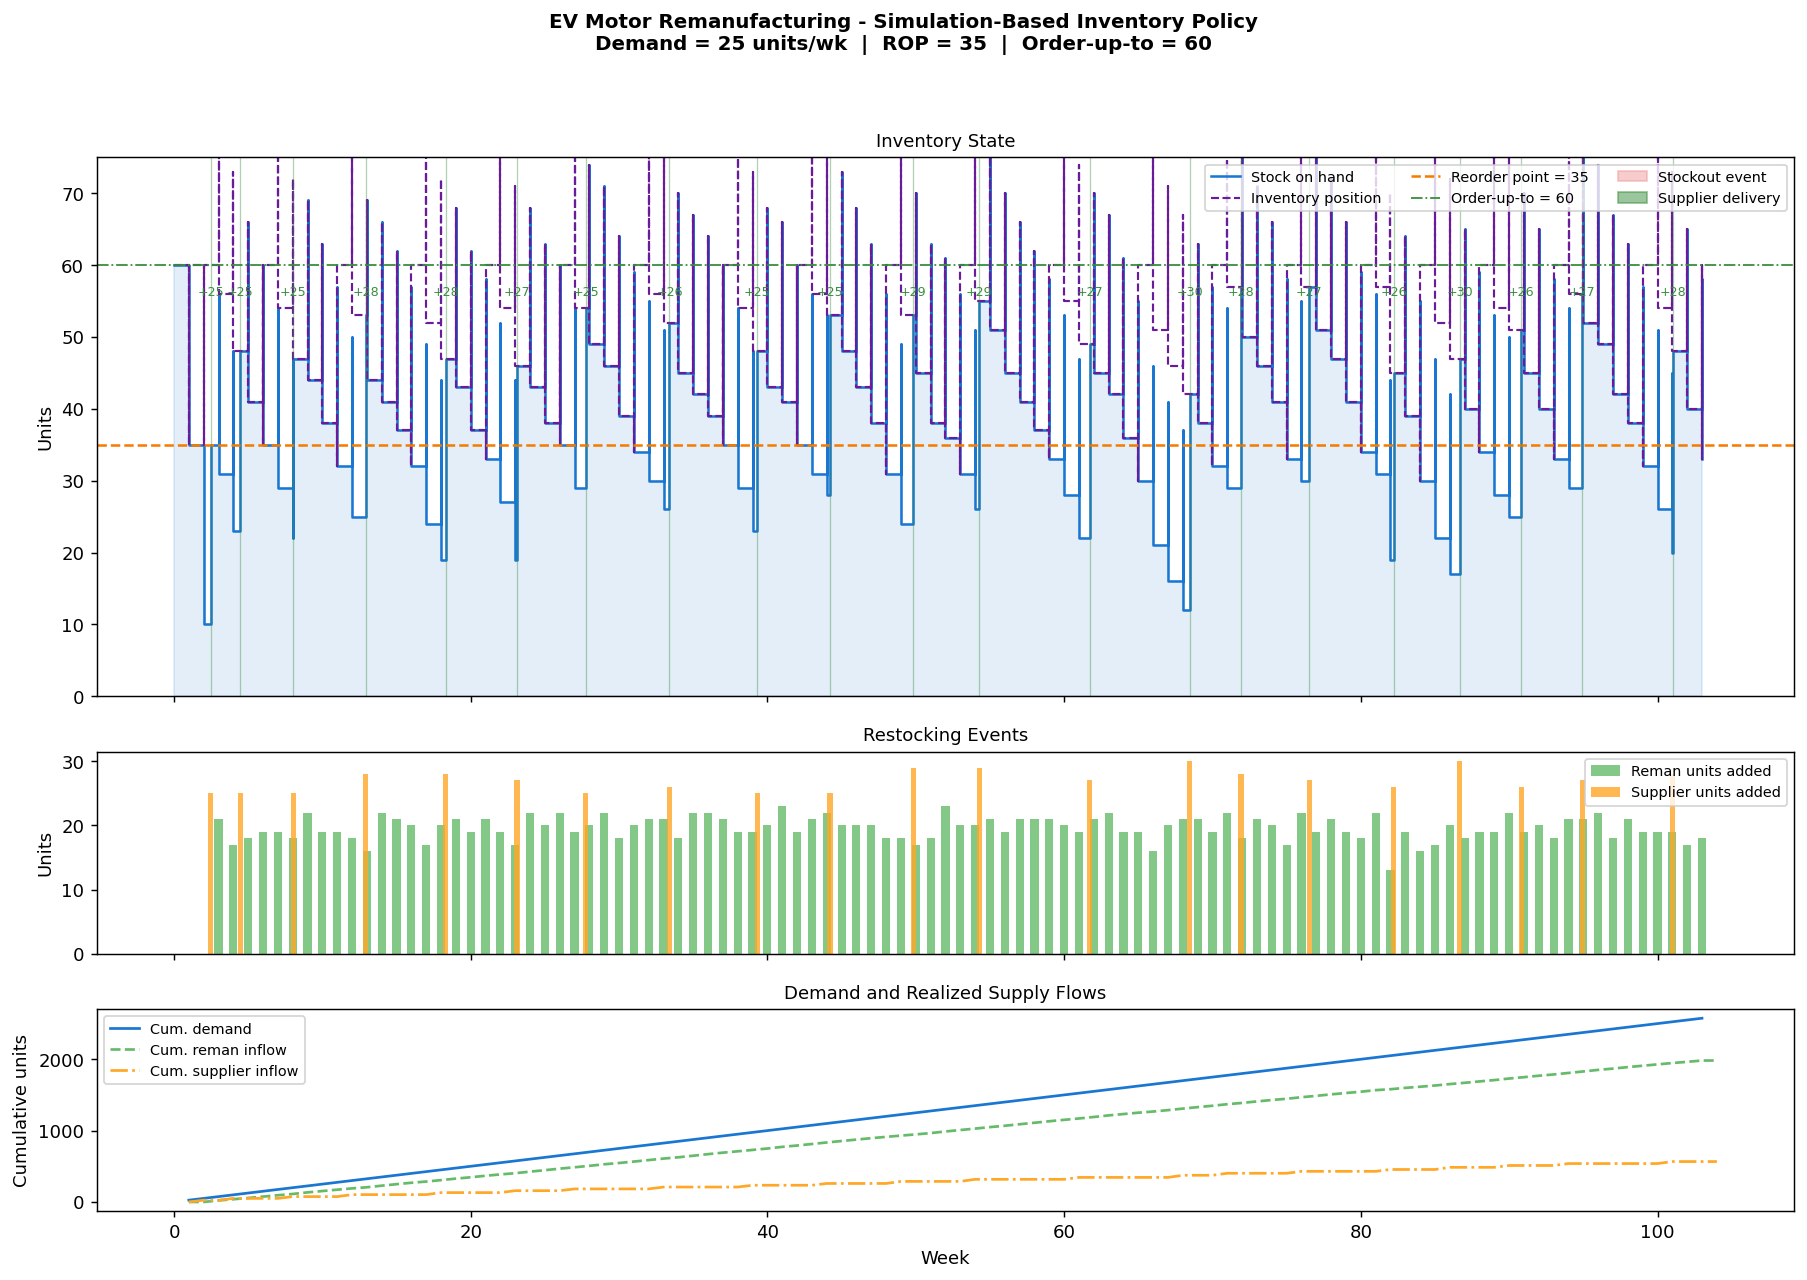

Plot saved: inventory_run.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [4, 1.5, 1.5]},
                         sharex=True)
fig.suptitle('EV Motor Remanufacturing - Simulation-Based Inventory Policy\n'
             f'Demand = {p.demand_per_week} units/wk  |  ROP = {p.reorder_point}  |  '
             f'Order-up-to = {p.max_stock}',
             fontsize=11, fontweight='bold')

# Panel 1: stock level and inventory position
ax = axes[0]
ax.step(sys.log_time, sys.log_stock, where='post', lw=1.4,
        color='#1976D2', label='Stock on hand')
ax.step(sys.log_time, sys.log_inventory_position, where='post', lw=1.2,
        color='#6A1B9A', linestyle='--', label='Inventory position')
ax.fill_between(sys.log_time, sys.log_stock,
                step='post', alpha=0.12, color='#1976D2')
ax.axhline(p.reorder_point, color='#F57C00', lw=1.4, ls='--',
           label=f'Reorder point = {p.reorder_point}')
ax.axhline(p.max_stock, color='#388E3C', lw=1.0, ls='-.',
           label=f'Order-up-to = {p.max_stock}')

for placed, qty, arrived in sys.log_orders:
    if arrived is not None:
        ax.axvline(arrived, color='#388E3C', lw=0.7, alpha=0.4)
        ax.annotate(f'+{qty}', xy=(arrived, p.max_stock * 0.93),
                    fontsize=7, color='#388E3C', ha='center')

for week, short in sys.log_stockouts:
    ax.axvspan(week - 1, week, color='#EF9A9A', alpha=0.35)

red_patch = mpatches.Patch(color='#EF9A9A', alpha=0.5, label='Stockout event')
green_line = mpatches.Patch(color='#388E3C', alpha=0.5, label='Supplier delivery')
ax.legend(handles=ax.get_legend_handles_labels()[0] + [red_patch, green_line],
          fontsize=8, loc='upper right', ncol=3)
ax.set_ylabel('Units')
ax.set_ylim(0, p.max_stock + 15)
ax.set_title('Inventory State', fontsize=10)

# Panel 2: inflows from reman and supplier
ax2 = axes[1]
if sys.log_reman_in:
    reman_weeks, reman_qty = zip(*sys.log_reman_in)
    ax2.bar(reman_weeks, reman_qty, width=0.55, color='#66BB6A',
            alpha=0.8, label='Reman units added')
if sys.log_supplier_in:
    supplier_weeks, supplier_qty = zip(*sys.log_supplier_in)
    ax2.bar(supplier_weeks, supplier_qty, width=0.35, color='#FFA726',
            alpha=0.8, label='Supplier units added')
ax2.set_ylabel('Units')
ax2.set_title('Restocking Events', fontsize=10)
ax2.legend(fontsize=8)

# Panel 3: cumulative demand vs realized replenishment
ax3 = axes[2]
demand_weeks = [d[0] for d in sys.log_demand]
cum_demand = np.cumsum([d[1] for d in sys.log_demand])
reman_series = pd.Series(0, index=range(1, p.sim_weeks + 1))
supplier_series = pd.Series(0, index=range(1, p.sim_weeks + 1))
for wk, qty in sys.log_reman_in:
    wk_int = int(wk)
    if wk_int in reman_series.index:
        reman_series[wk_int] += qty
for wk, qty in sys.log_supplier_in:
    wk_int = int(wk)
    if wk_int in supplier_series.index:
        supplier_series[wk_int] += qty
cum_reman = reman_series.cumsum()
cum_supplier = supplier_series.cumsum()

ax3.plot(demand_weeks, cum_demand, color='#1976D2', lw=1.5, label='Cum. demand')
ax3.plot(cum_reman.index, cum_reman.values, color='#66BB6A',
         lw=1.5, ls='--', label='Cum. reman inflow')
ax3.plot(cum_supplier.index, cum_supplier.values, color='#FFA726',
         lw=1.5, ls='-.', label='Cum. supplier inflow')
ax3.set_xlabel('Week')
ax3.set_ylabel('Cumulative units')
ax3.set_title('Demand and Realized Supply Flows', fontsize=10)
ax3.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('inventory_run.png', bbox_inches='tight')
plt.show()
print('Plot saved: inventory_run.png')
